In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

In [2]:
LOOKBACK = 180
HORIZON = 7   # change to 1, 7, or 30
CUTOFF = pd.Timestamp("2016-01-01")

SAVE_DIR = f"xgboost_sirikit_{HORIZON}day"
os.makedirs(SAVE_DIR, exist_ok=True)

np.random.seed(42)

In [3]:
CSV_PATH = r"MSEA-Res_database_v2/Dynamic_components/Level2/Level2_5140_1974_Sirikit.csv"

df = pd.read_csv(CSV_PATH)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").dropna(subset=["Storage_km3"]).reset_index(drop=True)

print("Data shape:", df.shape)
print(df.head())
print(df.tail())

Data shape: (13169, 2)
        Date  Storage_km3
0 1987-12-12     4.064504
1 1987-12-13     4.065823
2 1987-12-14     4.067143
3 1987-12-15     4.068463
4 1987-12-16     4.069783
            Date  Storage_km3
13164 2023-12-27     5.316066
13165 2023-12-28     5.314915
13166 2023-12-29     5.313879
13167 2023-12-30     5.312958
13168 2023-12-31     5.312153


In [4]:
train_df = df[df["Date"] < CUTOFF].copy()
test_df  = df[df["Date"] >= CUTOFF].copy()

print("Train:", train_df["Date"].min(), "→", train_df["Date"].max(), "n =", len(train_df))
print("Test :", test_df["Date"].min(), "→", test_df["Date"].max(), "n =", len(test_df))

Train: 1987-12-12 00:00:00 → 2015-12-31 00:00:00 n = 10247
Test : 2016-01-01 00:00:00 → 2023-12-31 00:00:00 n = 2922


In [5]:
x_scaler = StandardScaler().fit(train_df[["Storage_km3"]])
y_scaler = x_scaler   # for univariate case, input and target are same variable

train_s = x_scaler.transform(train_df[["Storage_km3"]]).astype(np.float32)
test_s  = x_scaler.transform(test_df[["Storage_km3"]]).astype(np.float32)

print("train_s:", train_s.shape)
print("test_s :", test_s.shape)

train_s: (10247, 1)
test_s : (2922, 1)


In [6]:
def make_windows_multistep(series_2d, target_1d, lookback=180, horizon=7, stride=1):
    """
    series_2d: [T, num_features]
    target_1d: [T]
    
    returns:
        X: [N, lookback, num_features]
        y: [N, horizon]
    """
    X, y = [], []

    for i in range(0, len(series_2d) - lookback - horizon + 1, stride):
        X.append(series_2d[i:i+lookback, :])
        y.append(target_1d[i+lookback:i+lookback+horizon])

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)

    if horizon == 1:
        y = y.reshape(-1, 1)

    return X, y

In [7]:
X_train, y_train = make_windows_multistep(
    train_s,
    train_s[:, 0],
    lookback=LOOKBACK,
    horizon=HORIZON
)

X_test, y_test = make_windows_multistep(
    test_s,
    test_s[:, 0],
    lookback=LOOKBACK,
    horizon=HORIZON
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (10061, 180, 1)
y_train: (10061, 7)
X_test : (2736, 180, 1)
y_test : (2736, 7)


In [8]:
N_train, T, F = X_train.shape
N_test = X_test.shape[0]

X_train_xgb = X_train.reshape(N_train, T * F)
X_test_xgb  = X_test.reshape(N_test, T * F)

print("X_train_xgb:", X_train_xgb.shape)
print("X_test_xgb :", X_test_xgb.shape)

X_train_xgb: (10061, 180)
X_test_xgb : (2736, 180)


In [9]:
VAL_FRAC = 0.15

n_val = int(len(X_train_xgb) * VAL_FRAC)

X_tr = X_train_xgb[:-n_val]
y_tr = y_train[:-n_val]

X_val = X_train_xgb[-n_val:]
y_val = y_train[-n_val:]

print("X_tr :", X_tr.shape, y_tr.shape)
print("X_val:", X_val.shape, y_val.shape)

X_tr : (8552, 180) (8552, 7)
X_val: (1509, 180) (1509, 7)


In [11]:
models = []
val_rmse_per_step = []

for h in range(HORIZON):
    print(f"\nTraining XGBoost for forecast step {h+1}/{HORIZON}")

    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=1200,
        learning_rate=0.02,
        max_depth=3,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=3,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=0,
        tree_method="hist",
        n_jobs=-1
    )

    model.fit(
        X_tr,
        y_tr[:, h],
        eval_set=[(X_val, y_val[:, h])],
        verbose=False
    )

    val_pred_h = model.predict(X_val)
    val_rmse_h = np.sqrt(mean_squared_error(y_val[:, h], val_pred_h))

    print(f"Validation RMSE scaled, step {h+1}: {val_rmse_h:.6f}")

    models.append(model)
    val_rmse_per_step.append(val_rmse_h)

print("\nDone training all XGBoost horizon models.")


Training XGBoost for forecast step 1/7
Validation RMSE scaled, step 1: 0.020116

Training XGBoost for forecast step 2/7
Validation RMSE scaled, step 2: 0.033980

Training XGBoost for forecast step 3/7
Validation RMSE scaled, step 3: 0.049241

Training XGBoost for forecast step 4/7
Validation RMSE scaled, step 4: 0.065695

Training XGBoost for forecast step 5/7
Validation RMSE scaled, step 5: 0.083078

Training XGBoost for forecast step 6/7
Validation RMSE scaled, step 6: 0.101633

Training XGBoost for forecast step 7/7
Validation RMSE scaled, step 7: 0.121665

Done training all XGBoost horizon models.


In [12]:
# import joblib
# import os

# MODEL_DIR = f"{SAVE_DIR}/models"
# os.makedirs(MODEL_DIR, exist_ok=True)

# for h, model in enumerate(models):
#     joblib.dump(model, f"{MODEL_DIR}/xgboost_{HORIZON}day_step_{h+1:02d}.joblib")

# print(f"Saved {len(models)} XGBoost models to:", MODEL_DIR)

In [13]:
y_pred_s = np.zeros_like(y_test, dtype=np.float32)

for h, model in enumerate(models):
    y_pred_s[:, h] = model.predict(X_test_xgb)

print("y_pred_s:", y_pred_s.shape)
print("y_test   :", y_test.shape)

y_pred_s: (2736, 7)
y_test   : (2736, 7)


In [14]:
y_pred = y_scaler.inverse_transform(y_pred_s.reshape(-1, 1)).reshape(-1, HORIZON)
y_true = y_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1, HORIZON)

print("y_pred:", y_pred.shape)
print("y_true:", y_true.shape)

y_pred: (2736, 7)
y_true: (2736, 7)


In [15]:
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
mae = np.mean(np.abs(y_true - y_pred))
r2 = r2_score(y_true.reshape(-1), y_pred.reshape(-1))

print(f"\n[XGBoost Test Forecast | Horizon={HORIZON}]")
print(f"RMSE = {rmse:.6f} km³")
print(f"MAE  = {mae:.6f} km³")
print(f"R²   = {r2:.6f}")


[XGBoost Test Forecast | Horizon=7]
RMSE = 0.117644 km³
MAE  = 0.076328 km³
R²   = 0.990571


In [16]:
rows = []

print("\nPer-step test metrics:")
for h in range(HORIZON):
    rmse_h = np.sqrt(mean_squared_error(y_true[:, h], y_pred[:, h]))
    mae_h = mean_absolute_error(y_true[:, h], y_pred[:, h])
    r2_h = r2_score(y_true[:, h], y_pred[:, h])

    rows.append({
        "Model": "XGBoost",
        "Horizon": HORIZON,
        "Step": h + 1,
        "RMSE_km3": rmse_h,
        "MAE_km3": mae_h,
        "R2": r2_h
    })

    print(f"Day {h+1:02d}: RMSE={rmse_h:.6f} | MAE={mae_h:.6f} | R²={r2_h:.6f}")

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv(f"{SAVE_DIR}/xgboost_{HORIZON}day_per_step_metrics.csv", index=False)

metrics_df.head()


Per-step test metrics:
Day 01: RMSE=0.034378 | MAE=0.022835 | R²=0.999197
Day 02: RMSE=0.056176 | MAE=0.039339 | R²=0.997854
Day 03: RMSE=0.080662 | MAE=0.057282 | R²=0.995571
Day 04: RMSE=0.105110 | MAE=0.075394 | R²=0.992473
Day 05: RMSE=0.130607 | MAE=0.093891 | R²=0.988369
Day 06: RMSE=0.156401 | MAE=0.112988 | R²=0.983308
Day 07: RMSE=0.182947 | MAE=0.132567 | R²=0.977142


,Model,Horizon,Step,RMSE_km3,MAE_km3,R2
0,XGBoost,7,1,0.034378,0.022835,0.999197
1,XGBoost,7,2,0.056176,0.039339,0.997854
2,XGBoost,7,3,0.080662,0.057282,0.995571
3,XGBoost,7,4,0.105110,0.075394,0.992473
4,XGBoost,7,5,0.130607,0.093891,0.988369


In [17]:
np.save(f"{SAVE_DIR}/xgboost_{HORIZON}day_y_true.npy", y_true)
np.save(f"{SAVE_DIR}/xgboost_{HORIZON}day_y_pred.npy", y_pred)

summary = pd.DataFrame([{
    "Model": "XGBoost",
    "Horizon": HORIZON,
    "Overall_RMSE_km3": rmse,
    "Overall_MAE_km3": mae,
    "Overall_R2": r2
}])

summary.to_csv(f"{SAVE_DIR}/xgboost_{HORIZON}day_summary_metrics.csv", index=False)

summary

,Model,Horizon,Overall_RMSE_km3,Overall_MAE_km3,Overall_R2
0,XGBoost,7,0.117644,0.076328,0.990571


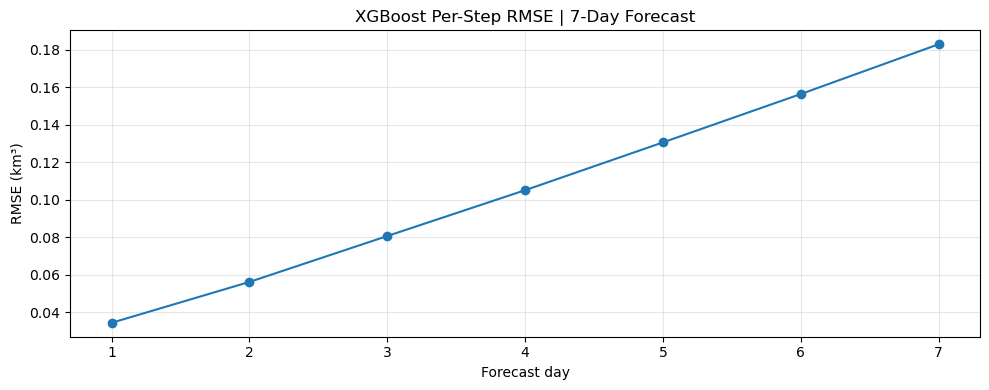

In [18]:
plt.figure(figsize=(10, 4))
plt.plot(metrics_df["Step"], metrics_df["RMSE_km3"], marker="o")
plt.xlabel("Forecast day")
plt.ylabel("RMSE (km³)")
plt.title(f"XGBoost Per-Step RMSE | {HORIZON}-Day Forecast")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/xgboost_{HORIZON}day_per_step_rmse.png", dpi=300)
plt.show()

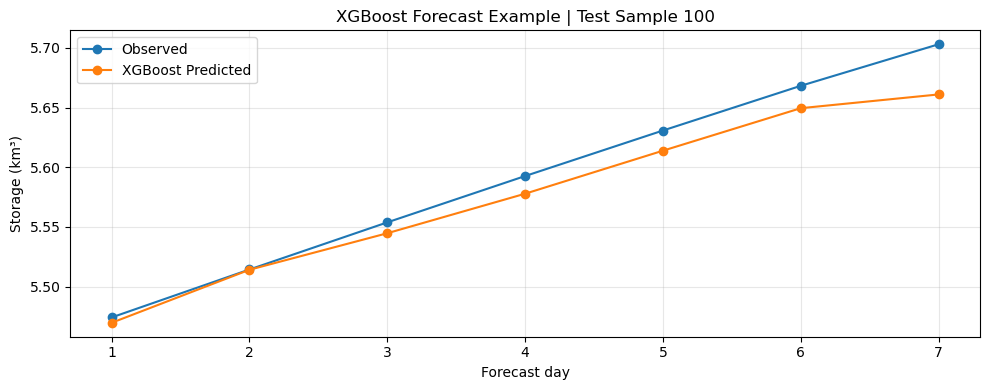

In [19]:
sample_idx = 100  # change this

plt.figure(figsize=(10, 4))
plt.plot(range(1, HORIZON + 1), y_true[sample_idx], marker="o", label="Observed")
plt.plot(range(1, HORIZON + 1), y_pred[sample_idx], marker="o", label="XGBoost Predicted")
plt.xlabel("Forecast day")
plt.ylabel("Storage (km³)")
plt.title(f"XGBoost Forecast Example | Test Sample {sample_idx}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/xgboost_{HORIZON}day_sample_forecast.png", dpi=300)
plt.show()

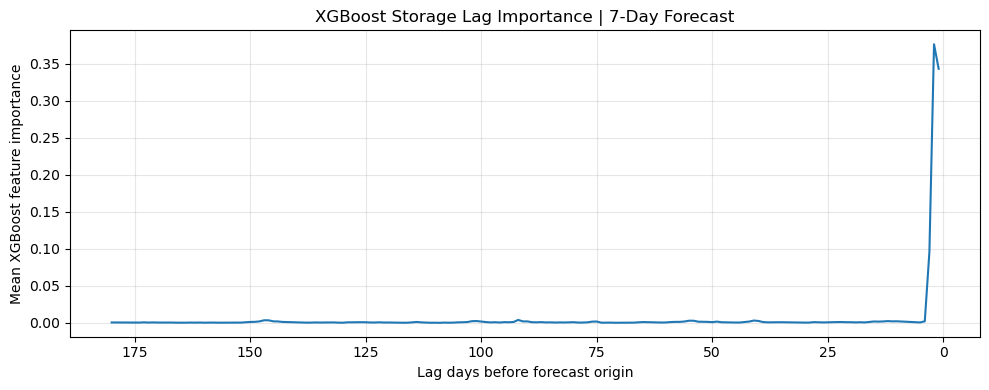

In [20]:
# Average feature importance across all horizon-specific models
importances = np.zeros(X_train_xgb.shape[1])

for model in models:
    importances += model.feature_importances_

importances /= len(models)

# reshape back to [lookback, features]
importance_by_lag = importances.reshape(LOOKBACK, F)

# For univariate, feature 0 = storage
storage_importance = importance_by_lag[:, 0]

# Convert index to lag days
# index 0 = oldest day, index 179 = most recent day
lags = np.arange(LOOKBACK, 0, -1)

plt.figure(figsize=(10, 4))
plt.plot(lags, storage_importance)
plt.xlabel("Lag days before forecast origin")
plt.ylabel("Mean XGBoost feature importance")
plt.title(f"XGBoost Storage Lag Importance | {HORIZON}-Day Forecast")
plt.gca().invert_xaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/xgboost_{HORIZON}day_lag_importance.png", dpi=300)
plt.show()

In [21]:
xgb_result_row = {
    "Model": "XGBoost",
    "Input": "Storage",
    "Lookback": LOOKBACK,
    "Horizon": HORIZON,
    "RMSE_km3": rmse,
    "MAE_km3": mae,
    "R2": r2
}

xgb_result_df = pd.DataFrame([xgb_result_row])
xgb_result_df

,Model,Input,Lookback,Horizon,RMSE_km3,MAE_km3,R2
0,XGBoost,Storage,180,7,0.117644,0.076328,0.990571


In [22]:
xgb_result_df.to_csv(f"{SAVE_DIR}/xgboost_{HORIZON}day_final_result_row.csv", index=False)

In [23]:
X_train_rf = X_train.reshape(X_train.shape[0], -1)
X_test_rf  = X_test.reshape(X_test.shape[0], -1)

In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import joblib
import os

models_rf = []
val_rmse_per_step_rf = []

MODEL_DIR = f"{SAVE_DIR}/random_forest_models"
os.makedirs(MODEL_DIR, exist_ok=True)

for h in range(HORIZON):
    print(f"\nTraining Random Forest for forecast step {h+1}/{HORIZON}")

    rf = RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=0,
        n_jobs=-1
    )

    rf.fit(X_tr, y_tr[:, h])

    val_pred_h = rf.predict(X_val)
    val_rmse_h = np.sqrt(mean_squared_error(y_val[:, h], val_pred_h))

    print(f"Validation RMSE scaled, step {h+1}: {val_rmse_h:.6f}")

    models_rf.append(rf)
    val_rmse_per_step_rf.append(val_rmse_h)

    joblib.dump(rf, f"{MODEL_DIR}/rf_{HORIZON}day_step_{h+1:02d}.joblib")

print("\nDone training and saving all Random Forest horizon models.")


Training Random Forest for forecast step 1/7
Validation RMSE scaled, step 1: 0.083622

Training Random Forest for forecast step 2/7
Validation RMSE scaled, step 2: 0.099396

Training Random Forest for forecast step 3/7
Validation RMSE scaled, step 3: 0.117257

Training Random Forest for forecast step 4/7
Validation RMSE scaled, step 4: 0.137921

Training Random Forest for forecast step 5/7
Validation RMSE scaled, step 5: 0.157736

Training Random Forest for forecast step 6/7
Validation RMSE scaled, step 6: 0.178582

Training Random Forest for forecast step 7/7
Validation RMSE scaled, step 7: 0.197785

Done training and saving all Random Forest horizon models.


In [25]:
y_pred_s_rf = np.zeros_like(y_test, dtype=np.float32)

for h, rf in enumerate(models_rf):
    y_pred_s_rf[:, h] = rf.predict(X_test_xgb)  # same flattened test input

print("y_pred_s_rf:", y_pred_s_rf.shape)
print("y_test     :", y_test.shape)

y_pred_s_rf: (2736, 7)
y_test     : (2736, 7)


In [26]:
y_pred_rf = y_scaler.inverse_transform(y_pred_s_rf.reshape(-1, 1)).reshape(-1, HORIZON)
y_true_rf = y_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1, HORIZON)

In [27]:
from sklearn.metrics import mean_absolute_error, r2_score

rmse_rf = np.sqrt(np.mean((y_true_rf - y_pred_rf) ** 2))
mae_rf = np.mean(np.abs(y_true_rf - y_pred_rf))
r2_rf = r2_score(y_true_rf.reshape(-1), y_pred_rf.reshape(-1))

print(f"\n[Random Forest Test Forecast | Horizon={HORIZON}]")
print(f"RMSE = {rmse_rf:.6f} km³")
print(f"MAE  = {mae_rf:.6f} km³")
print(f"R²   = {r2_rf:.6f}")


[Random Forest Test Forecast | Horizon=7]
RMSE = 0.200706 km³
MAE  = 0.139390 km³
R²   = 0.972556


In [28]:
rf_result_df = pd.DataFrame([{
    "Model": "Random Forest",
    "Input": "Storage",
    "Lookback": LOOKBACK,
    "Horizon": HORIZON,
    "RMSE_km3": rmse_rf,
    "MAE_km3": mae_rf,
    "R2": r2_rf
}])

rf_result_df.to_csv(f"{SAVE_DIR}/random_forest_{HORIZON}day_final_result_row.csv", index=False)
rf_result_df

,Model,Input,Lookback,Horizon,RMSE_km3,MAE_km3,R2
0,Random Forest,Storage,180,7,0.200706,0.13939,0.972556


In [29]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print(LOOKBACK, HORIZON)

(10061, 180, 1) (10061, 7)
(2736, 180, 1) (2736, 7)
180 7


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [15]:
HORIZON = 7
LOOKBACK = 180

SAVE_DIR = f"gru_sirikit_{HORIZON}day"
os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device("cpu")
print("Using device:", device)

torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


In [16]:
VAL_FRAC = 0.15

n_val = int(len(X_train) * VAL_FRAC)

X_tr = X_train[:-n_val]
y_tr = y_train[:-n_val]

X_val = X_train[-n_val:]
y_val = y_train[-n_val:]

print("X_tr :", X_tr.shape, y_tr.shape)
print("X_val:", X_val.shape, y_val.shape)
print("X_test:", X_test.shape, y_test.shape)

X_tr : (8552, 180, 1) (8552, 7)
X_val: (1509, 180, 1) (1509, 7)
X_test: (2736, 180, 1) (2736, 7)


In [17]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

        if self.y.ndim == 1:
            self.y = self.y.reshape(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


batch_size = 128

train_loader = DataLoader(
    SeqDataset(X_tr, y_tr),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    SeqDataset(X_val, y_val),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    SeqDataset(X_test, y_test),
    batch_size=batch_size,
    shuffle=False
)

In [18]:
class GRUForecaster(nn.Module):
    def __init__(
        self,
        input_dim=1,
        hidden_dim=128,
        num_layers=2,
        dropout=0.3,
        out_dim=7
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False
        )

        self.head = nn.Linear(hidden_dim, out_dim)

    def forward(self, x, return_hidden=False):
        out, h = self.gru(x)          # out: [B, T, hidden_dim]
        h_last = out[:, -1, :]       # [B, hidden_dim]
        yhat = self.head(h_last)     # [B, horizon]

        if return_hidden:
            return yhat, out

        return yhat

In [19]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    loss_fn = nn.MSELoss()

    total_loss = 0.0
    n = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)

        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(xb)
        n += len(xb)

    return total_loss / n


@torch.no_grad()
def evaluate_scaled(model, loader, device):
    model.eval()

    preds = []
    trues = []

    for xb, yb in loader:
        xb = xb.to(device)

        pred = model(xb).cpu().numpy()

        preds.append(pred)
        trues.append(yb.numpy())

    preds = np.vstack(preds)
    trues = np.vstack(trues)

    rmse = np.sqrt(np.mean((trues - preds) ** 2))
    mae = np.mean(np.abs(trues - preds))

    return rmse, mae

In [36]:
input_dim = X_train.shape[2]

gru = GRUForecaster(
    input_dim=input_dim,
    hidden_dim=128,
    num_layers=2,
    dropout=0.3,
    out_dim=HORIZON
).to(device)

optimizer = torch.optim.AdamW(gru.parameters(), lr=1e-3, weight_decay=1e-5)

best_val_rmse = float("inf")
best_state = None

patience = 20
bad = 0
max_epochs = 300

history = []

for epoch in range(1, max_epochs + 1):
    train_loss = train_one_epoch(gru, train_loader, optimizer, device)
    val_rmse, val_mae = evaluate_scaled(gru, val_loader, device)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_rmse_scaled": val_rmse,
        "val_mae_scaled": val_mae
    })

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | "
            f"train loss={train_loss:.6f} | "
            f"val RMSE={val_rmse:.6f} | "
            f"val MAE={val_mae:.6f}"
        )

    if val_rmse < best_val_rmse - 1e-6:
        best_val_rmse = val_rmse
        bad = 0
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in gru.state_dict().items()
        }

        torch.save({
            "model_state": best_state,
            "config": {
                "model": "GRU",
                "input_dim": input_dim,
                "hidden_dim": 128,
                "num_layers": 2,
                "dropout": 0.3,
                "out_dim": HORIZON,
                "lookback": LOOKBACK
            },
            "best_val_rmse_scaled": best_val_rmse
        }, f"{SAVE_DIR}/gru_{HORIZON}day_best.pt")

    else:
        bad += 1

    if bad >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

gru.load_state_dict({k: v.to(device) for k, v in best_state.items()})
gru.eval()

print("Best validation RMSE scaled:", best_val_rmse)

Epoch 001 | train loss=0.147645 | val RMSE=0.133622 | val MAE=0.093345
Epoch 010 | train loss=0.004546 | val RMSE=0.047918 | val MAE=0.028002
Epoch 020 | train loss=0.002883 | val RMSE=0.049103 | val MAE=0.034493
Epoch 030 | train loss=0.002147 | val RMSE=0.049539 | val MAE=0.040226
Epoch 040 | train loss=0.001724 | val RMSE=0.036562 | val MAE=0.026373
Epoch 050 | train loss=0.001466 | val RMSE=0.031652 | val MAE=0.019789
Epoch 060 | train loss=0.001303 | val RMSE=0.031839 | val MAE=0.019898
Epoch 070 | train loss=0.001186 | val RMSE=0.027671 | val MAE=0.013601
Epoch 080 | train loss=0.001103 | val RMSE=0.029426 | val MAE=0.016464
Epoch 090 | train loss=0.001070 | val RMSE=0.028989 | val MAE=0.015892
Epoch 100 | train loss=0.001007 | val RMSE=0.030435 | val MAE=0.018430
Early stopping at epoch 106
Best validation RMSE scaled: 0.027130894


In [20]:
device = torch.device("cpu")

checkpoint_path = f"gru_sirikit_7day/gru_{HORIZON}day_best.pt"

ckpt = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False
)

config = ckpt["config"]

gru = GRUForecaster(
    input_dim=config["input_dim"],
    hidden_dim=config["hidden_dim"],
    num_layers=config["num_layers"],
    dropout=config["dropout"],
    out_dim=config["out_dim"]
).to(device)

gru.load_state_dict(ckpt["model_state"])
gru.eval()

print("GRU model reloaded successfully")
print("Best validation RMSE scaled:", ckpt["best_val_rmse_scaled"])

GRU model reloaded successfully
Best validation RMSE scaled: 0.027130894


In [21]:
@torch.no_grad()
def predict_model(model, loader, device):
    model.eval()

    preds = []
    trues = []

    for xb, yb in loader:
        xb = xb.to(device)

        pred = model(xb).cpu().numpy()

        preds.append(pred)
        trues.append(yb.numpy())

    preds = np.vstack(preds)
    trues = np.vstack(trues)

    return preds, trues


y_pred_s, y_true_s = predict_model(gru, test_loader, device)

print("y_pred_s:", y_pred_s.shape)
print("y_true_s:", y_true_s.shape)

y_pred_s: (2736, 7)
y_true_s: (2736, 7)


In [22]:
y_pred = y_scaler.inverse_transform(y_pred_s.reshape(-1, 1)).reshape(-1, HORIZON)
y_true = y_scaler.inverse_transform(y_true_s.reshape(-1, 1)).reshape(-1, HORIZON)

print("y_pred:", y_pred.shape)
print("y_true:", y_true.shape)

y_pred: (2736, 7)
y_true: (2736, 7)


In [23]:
print("Available scaler names:")
print("y_scaler" in globals())
print("x_scaler" in globals())
print("scaler" in globals())

Available scaler names:
True
True
False


In [24]:
rmse_gru = np.sqrt(np.mean((y_true - y_pred) ** 2))
mae_gru = np.mean(np.abs(y_true - y_pred))
r2_gru = r2_score(y_true.reshape(-1), y_pred.reshape(-1))

print(f"\n[GRU Test Forecast | Horizon={HORIZON}]")
print(f"RMSE = {rmse_gru:.6f} km³")
print(f"MAE  = {mae_gru:.6f} km³")
print(f"R²   = {r2_gru:.6f}")


[GRU Test Forecast | Horizon=7]
RMSE = 0.049856 km³
MAE  = 0.029137 km³
R²   = 0.998307


In [25]:
rows = []

print("\nPer-step GRU metrics:")

for h in range(HORIZON):
    rmse_h = np.sqrt(mean_squared_error(y_true[:, h], y_pred[:, h]))
    mae_h = mean_absolute_error(y_true[:, h], y_pred[:, h])
    r2_h = r2_score(y_true[:, h], y_pred[:, h])

    rows.append({
        "Model": "GRU",
        "Input": "Storage",
        "Lookback": LOOKBACK,
        "Horizon": HORIZON,
        "Step": h + 1,
        "RMSE_km3": rmse_h,
        "MAE_km3": mae_h,
        "R2": r2_h
    })

    print(
        f"Day {h+1:02d}: "
        f"RMSE={rmse_h:.6f} | "
        f"MAE={mae_h:.6f} | "
        f"R²={r2_h:.6f}"
    )

gru_metrics_df = pd.DataFrame(rows)
gru_metrics_df.to_csv(f"{SAVE_DIR}/gru_{HORIZON}day_per_step_metrics.csv", index=False)

gru_metrics_df.head()


Per-step GRU metrics:
Day 01: RMSE=0.018385 | MAE=0.012283 | R²=0.999770
Day 02: RMSE=0.019740 | MAE=0.013332 | R²=0.999735
Day 03: RMSE=0.027709 | MAE=0.017999 | R²=0.999477
Day 04: RMSE=0.039289 | MAE=0.025367 | R²=0.998948
Day 05: RMSE=0.052720 | MAE=0.034435 | R²=0.998105
Day 06: RMSE=0.067439 | MAE=0.044657 | R²=0.996897
Day 07: RMSE=0.083861 | MAE=0.055885 | R²=0.995197


,Model,Input,Lookback,Horizon,Step,RMSE_km3,MAE_km3,R2
0,GRU,Storage,180,7,1,0.018385,0.012283,0.999770
1,GRU,Storage,180,7,2,0.019740,0.013332,0.999735
2,GRU,Storage,180,7,3,0.027709,0.017999,0.999477
3,GRU,Storage,180,7,4,0.039289,0.025367,0.998948
4,GRU,Storage,180,7,5,0.052720,0.034435,0.998105


In [26]:
gru_result_df = pd.DataFrame([{
    "Model": "GRU",
    "Input": "Storage",
    "Lookback": LOOKBACK,
    "Horizon": HORIZON,
    "RMSE_km3": rmse_gru,
    "MAE_km3": mae_gru,
    "R2": r2_gru
}])

gru_result_df.to_csv(f"{SAVE_DIR}/gru_{HORIZON}day_final_result_row.csv", index=False)

gru_result_df

,Model,Input,Lookback,Horizon,RMSE_km3,MAE_km3,R2
0,GRU,Storage,180,7,0.049856,0.029137,0.998307


In [27]:
np.save(f"{SAVE_DIR}/gru_{HORIZON}day_y_true.npy", y_true)
np.save(f"{SAVE_DIR}/gru_{HORIZON}day_y_pred.npy", y_pred)

history_df = pd.DataFrame(history)
history_df.to_csv(f"{SAVE_DIR}/gru_{HORIZON}day_training_history.csv", index=False)

print("Saved GRU predictions and training history.")

NameError: name 'history' is not defined

In [28]:
SAVE_DIR = f"lstm_sirikit_{HORIZON}day"
os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device("cpu")
print("Using device:", device)

torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


In [29]:
class LSTMForecaster(nn.Module):
    def __init__(
        self,
        input_dim=1,
        hidden_dim=128,
        num_layers=2,
        dropout=0.3,
        out_dim=7
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False
        )

        self.head = nn.Linear(hidden_dim, out_dim)

    def forward(self, x, return_hidden=False):
        out, (h, c) = self.lstm(x)   # out: [B, T, hidden_dim]
        h_last = out[:, -1, :]       # [B, hidden_dim]
        yhat = self.head(h_last)     # [B, horizon]

        if return_hidden:
            return yhat, out

        return yhat

In [30]:
input_dim = X_train.shape[2]

lstm = LSTMForecaster(
    input_dim=input_dim,
    hidden_dim=128,
    num_layers=2,
    dropout=0.3,
    out_dim=HORIZON
).to(device)

optimizer = torch.optim.AdamW(lstm.parameters(), lr=1e-3, weight_decay=1e-5)

best_val_rmse = float("inf")
best_state = None

patience = 20
bad = 0
max_epochs = 300

history = []

for epoch in range(1, max_epochs + 1):
    train_loss = train_one_epoch(lstm, train_loader, optimizer, device)
    val_rmse, val_mae = evaluate_scaled(lstm, val_loader, device)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_rmse_scaled": val_rmse,
        "val_mae_scaled": val_mae
    })

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | "
            f"train loss={train_loss:.6f} | "
            f"val RMSE={val_rmse:.6f} | "
            f"val MAE={val_mae:.6f}"
        )

    if val_rmse < best_val_rmse - 1e-6:
        best_val_rmse = val_rmse
        bad = 0
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in lstm.state_dict().items()
        }

        torch.save({
            "model_state": best_state,
            "config": {
                "model": "LSTM",
                "input_dim": input_dim,
                "hidden_dim": 128,
                "num_layers": 2,
                "dropout": 0.3,
                "out_dim": HORIZON,
                "lookback": LOOKBACK
            },
            "best_val_rmse_scaled": best_val_rmse
        }, f"{SAVE_DIR}/lstm_{HORIZON}day_best.pt")

    else:
        bad += 1

    if bad >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

lstm.load_state_dict({k: v.to(device) for k, v in best_state.items()})
lstm.eval()

print("Best validation RMSE scaled:", best_val_rmse)

Epoch 001 | train loss=0.238782 | val RMSE=0.142648 | val MAE=0.101062
Epoch 010 | train loss=0.006144 | val RMSE=0.060826 | val MAE=0.042748
Epoch 020 | train loss=0.003318 | val RMSE=0.059015 | val MAE=0.048033
Epoch 030 | train loss=0.002370 | val RMSE=0.037487 | val MAE=0.023138
Epoch 040 | train loss=0.001917 | val RMSE=0.034574 | val MAE=0.021417
Epoch 050 | train loss=0.001633 | val RMSE=0.033890 | val MAE=0.021480
Epoch 060 | train loss=0.001429 | val RMSE=0.031474 | val MAE=0.017354
Epoch 070 | train loss=0.001251 | val RMSE=0.028335 | val MAE=0.015066
Epoch 080 | train loss=0.001197 | val RMSE=0.027322 | val MAE=0.014586
Epoch 090 | train loss=0.001201 | val RMSE=0.030695 | val MAE=0.019636
Epoch 100 | train loss=0.001026 | val RMSE=0.028337 | val MAE=0.016329
Epoch 110 | train loss=0.001036 | val RMSE=0.031031 | val MAE=0.021211
Early stopping at epoch 115
Best validation RMSE scaled: 0.025597226


In [31]:
y_pred_s, y_true_s = predict_model(lstm, test_loader, device)

print("y_pred_s:", y_pred_s.shape)
print("y_true_s:", y_true_s.shape)

y_pred_s: (2736, 7)
y_true_s: (2736, 7)


In [32]:
scaler = y_scaler   # use this if your notebook has y_scaler

y_pred = scaler.inverse_transform(y_pred_s.reshape(-1, 1)).reshape(-1, HORIZON)
y_true = scaler.inverse_transform(y_true_s.reshape(-1, 1)).reshape(-1, HORIZON)

print("y_pred:", y_pred.shape)
print("y_true:", y_true.shape)

y_pred: (2736, 7)
y_true: (2736, 7)


In [33]:
rmse_lstm = np.sqrt(np.mean((y_true - y_pred) ** 2))
mae_lstm = np.mean(np.abs(y_true - y_pred))
r2_lstm = r2_score(y_true.reshape(-1), y_pred.reshape(-1))

print(f"\n[LSTM Test Forecast | Horizon={HORIZON}]")
print(f"RMSE = {rmse_lstm:.6f} km³")
print(f"MAE  = {mae_lstm:.6f} km³")
print(f"R²   = {r2_lstm:.6f}")


[LSTM Test Forecast | Horizon=7]
RMSE = 0.048966 km³
MAE  = 0.027651 km³
R²   = 0.998367


In [34]:
rows = []

print("\nPer-step LSTM metrics:")

for h in range(HORIZON):
    rmse_h = np.sqrt(mean_squared_error(y_true[:, h], y_pred[:, h]))
    mae_h = mean_absolute_error(y_true[:, h], y_pred[:, h])
    r2_h = r2_score(y_true[:, h], y_pred[:, h])

    rows.append({
        "Model": "LSTM",
        "Input": "Storage",
        "Lookback": LOOKBACK,
        "Horizon": HORIZON,
        "Step": h + 1,
        "RMSE_km3": rmse_h,
        "MAE_km3": mae_h,
        "R2": r2_h
    })

    print(
        f"Day {h+1:02d}: "
        f"RMSE={rmse_h:.6f} | "
        f"MAE={mae_h:.6f} | "
        f"R²={r2_h:.6f}"
    )

lstm_metrics_df = pd.DataFrame(rows)
lstm_metrics_df.to_csv(f"{SAVE_DIR}/lstm_{HORIZON}day_per_step_metrics.csv", index=False)

lstm_metrics_df.head()


Per-step LSTM metrics:
Day 01: RMSE=0.015988 | MAE=0.010099 | R²=0.999826
Day 02: RMSE=0.020043 | MAE=0.012481 | R²=0.999727
Day 03: RMSE=0.027462 | MAE=0.017385 | R²=0.999487
Day 04: RMSE=0.037820 | MAE=0.023895 | R²=0.999026
Day 05: RMSE=0.050882 | MAE=0.032437 | R²=0.998235
Day 06: RMSE=0.066405 | MAE=0.043060 | R²=0.996991
Day 07: RMSE=0.083327 | MAE=0.054200 | R²=0.995258


,Model,Input,Lookback,Horizon,Step,RMSE_km3,MAE_km3,R2
0,LSTM,Storage,180,7,1,0.015988,0.010099,0.999826
1,LSTM,Storage,180,7,2,0.020043,0.012481,0.999727
2,LSTM,Storage,180,7,3,0.027462,0.017385,0.999487
3,LSTM,Storage,180,7,4,0.037820,0.023895,0.999026
4,LSTM,Storage,180,7,5,0.050882,0.032437,0.998235


In [53]:
import os
import numpy as np
import torch
import torch.nn as nn

device = torch.device("cpu")
print("Using device:", device)

SAVE_DIR = "sirikit/sirikit"
HORIZON = 7
LOOKBACK = 180

Using device: cpu


In [54]:
class BiLSTMBase(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=128, num_layers=1, out_dim=30):
        super().__init__()

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )

        self.head = nn.Linear(hidden_dim * 2, out_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        h_last = out[:, -1, :]
        return self.head(h_last)


class BiLSTMTopoAug(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=128, num_layers=1, topo_dim=3, out_dim=1):
        super().__init__()

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )

        self.head = nn.Sequential(
            nn.Linear(hidden_dim * 2 + topo_dim, 128),
            nn.ReLU(),
            nn.Linear(128, out_dim)
        )

    def forward(self, x, phi):
        out, _ = self.lstm(x)
        h_last = out[:, -1, :]
        z = torch.cat([h_last, phi], dim=1)
        return self.head(z)

In [55]:
base_ckpt_path = f"{SAVE_DIR}/7_day_bilstm_base_best_sirikit.pt"

ckpt_b = torch.load(
    base_ckpt_path,
    map_location=device,
    weights_only=False
)

base_best = BiLSTMBase(
    input_dim=ckpt_b["config"]["input_dim"],
    hidden_dim=ckpt_b["config"]["hidden_dim"],
    out_dim=ckpt_b["config"]["out_dim"]
).to(device)

base_best.load_state_dict(ckpt_b["model_state"])
base_best.eval()

print("Loaded base_best")
print("Baseline checkpoint RMSE:", ckpt_b["rmse"])

Loaded base_best
Baseline checkpoint RMSE: 0.040182304


In [56]:
aug_ckpt_path = f"{SAVE_DIR}/7_day_bilstm_topo_aug_best_sirikit.pt"

ckpt_a = torch.load(
    aug_ckpt_path,
    map_location=device,
    weights_only=False
)

aug_best = BiLSTMTopoAug(
    input_dim=ckpt_a["config"]["input_dim"],
    hidden_dim=ckpt_a["config"]["hidden_dim"],
    topo_dim=ckpt_a["config"]["topo_dim"],
    out_dim=ckpt_a["config"]["out_dim"]
).to(device)

aug_best.load_state_dict(ckpt_a["model_state"])
aug_best.eval()

print("Loaded aug_best")
print("Topo-aug checkpoint RMSE:", ckpt_a["rmse"])

Loaded aug_best
Topo-aug checkpoint RMSE: 0.033299208


In [57]:
mu = ckpt_a["zigzag_norm"]["mu"]
sd = ckpt_a["zigzag_norm"]["sd"]
keep = ckpt_a["zigzag_norm"]["keep_mask"]

phi_test_raw = np.load(f"{SAVE_DIR}/7_day_zigzag_test_per_sample.npy").astype(np.float32)

phi_test_k = phi_test_raw[:, keep]
phi_test_n = (phi_test_k - mu) / (sd + 1e-8)

print("Loaded and normalized phi_test_n")
print("keep mask:", keep)
print("phi_test_n shape:", phi_test_n.shape)

Loaded and normalized phi_test_n
keep mask: [ True False  True  True]
phi_test_n shape: (2736, 3)


In [58]:
print("base_best exists:", "base_best" in globals())
print("aug_best exists :", "aug_best" in globals())
print("phi_test_n exists:", "phi_test_n" in globals())

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("phi_test_n:", phi_test_n.shape)

base_best exists: True
aug_best exists : True
phi_test_n exists: True
X_test: (2736, 180, 1)
y_test: (2736, 7)
phi_test_n: (2736, 3)


In [59]:
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd
import torch

@torch.no_grad()
def predict_base(model, X_np, device, batch_size=256):
    model.eval()
    X = torch.tensor(X_np, dtype=torch.float32)
    preds = []

    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size].to(device)
        yhat = model(xb).cpu().numpy()
        preds.append(yhat)

    return np.vstack(preds)


@torch.no_grad()
def predict_aug(model, X_np, phi_np, device, batch_size=256):
    model.eval()
    X = torch.tensor(X_np, dtype=torch.float32)
    P = torch.tensor(phi_np, dtype=torch.float32)
    preds = []

    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size].to(device)
        pb = P[i:i+batch_size].to(device)
        yhat = model(xb, pb).cpu().numpy()
        preds.append(yhat)

    return np.vstack(preds)

In [60]:
# Predictions in scaled space
pred_b_s = predict_base(base_best, X_test, device)
pred_a_s = predict_aug(aug_best, X_test, phi_test_n, device)

y_true_s = y_test

print("pred_b_s:", pred_b_s.shape)
print("pred_a_s:", pred_a_s.shape)
print("y_true_s:", y_true_s.shape)

pred_b_s: (2736, 7)
pred_a_s: (2736, 7)
y_true_s: (2736, 7)


In [61]:
# Pick correct scaler
try:
    final_scaler = y_scaler
    print("Using y_scaler")
except NameError:
    final_scaler = scaler
    print("Using scaler")

# Inverse transform to km³
pred_b = final_scaler.inverse_transform(pred_b_s.reshape(-1, 1)).reshape(-1, HORIZON)
pred_a = final_scaler.inverse_transform(pred_a_s.reshape(-1, 1)).reshape(-1, HORIZON)
y_true = final_scaler.inverse_transform(y_true_s.reshape(-1, 1)).reshape(-1, HORIZON)

print("pred_b:", pred_b.shape)
print("pred_a:", pred_a.shape)
print("y_true:", y_true.shape)

Using y_scaler
pred_b: (2736, 7)
pred_a: (2736, 7)
y_true: (2736, 7)


In [62]:
# Final metrics in km³
rmse_b = np.sqrt(np.mean((y_true - pred_b) ** 2))
mae_b = np.mean(np.abs(y_true - pred_b))
r2_b = r2_score(y_true.reshape(-1), pred_b.reshape(-1))

rmse_tda = np.sqrt(np.mean((y_true - pred_a) ** 2))
mae_tda = np.mean(np.abs(y_true - pred_a))
r2_tda = r2_score(y_true.reshape(-1), pred_a.reshape(-1))

tda_compare_df = pd.DataFrame([
    {
        "Model": "BiLSTM",
        "Input": "Storage",
        "Lookback": LOOKBACK,
        "Horizon": HORIZON,
        "RMSE_km3": rmse_b,
        "MAE_km3": mae_b,
        "R2": r2_b
    },
    {
        "Model": "BiLSTM + Zigzag TDA",
        "Input": "Storage + Zigzag PH Features",
        "Lookback": LOOKBACK,
        "Horizon": HORIZON,
        "RMSE_km3": rmse_tda,
        "MAE_km3": mae_tda,
        "R2": r2_tda
    }
])

tda_compare_df

,Model,Input,Lookback,Horizon,RMSE_km3,MAE_km3,R2
0,BiLSTM,Storage,180,7,0.047816,0.027241,0.998442
1,BiLSTM + Zigzag TDA,Storage + Zigzag PH Features,180,7,0.039625,0.022847,0.998930


In [63]:
rmse_improvement = (rmse_b - rmse_tda) / rmse_b * 100
mae_improvement = (mae_b - mae_tda) / mae_b * 100

print(f"RMSE improvement from TDA: {rmse_improvement:.2f}%")
print(f"MAE improvement from TDA : {mae_improvement:.2f}%")

RMSE improvement from TDA: 17.13%
MAE improvement from TDA : 16.13%


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

device = torch.device("cpu")
print("Using device:", device)

HORIZON = 7
LOOKBACK = 180

SAVE_DIR = f"tcn_sirikit_{HORIZON}day"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


In [36]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (10061, 180, 1)
y_train: (10061, 7)
X_test : (2736, 180, 1)
y_test : (2736, 7)


In [37]:
VAL_FRAC = 0.15

n_val = int(len(X_train) * VAL_FRAC)

X_tr = X_train[:-n_val]
y_tr = y_train[:-n_val]

X_val = X_train[-n_val:]
y_val = y_train[-n_val:]

print("X_tr :", X_tr.shape, y_tr.shape)
print("X_val:", X_val.shape, y_val.shape)
print("X_test:", X_test.shape, y_test.shape)

X_tr : (8552, 180, 1) (8552, 7)
X_val: (1509, 180, 1) (1509, 7)
X_test: (2736, 180, 1) (2736, 7)


In [38]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

        if self.y.ndim == 1:
            self.y = self.y.reshape(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


batch_size = 128

train_loader = DataLoader(
    SeqDataset(X_tr, y_tr),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    SeqDataset(X_val, y_val),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    SeqDataset(X_test, y_test),
    batch_size=batch_size,
    shuffle=False
)

In [39]:
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        if self.chomp_size == 0:
            return x
        return x[:, :, :-self.chomp_size]


class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout):
        super().__init__()

        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size,
            padding=padding,
            dilation=dilation
        )
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size,
            padding=padding,
            dilation=dilation
        )
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.downsample = (
            nn.Conv1d(in_channels, out_channels, kernel_size=1)
            if in_channels != out_channels else None
        )

        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.conv1(x)
        out = self.chomp1(out)
        out = self.relu1(out)
        out = self.dropout1(out)

        out = self.conv2(out)
        out = self.chomp2(out)
        out = self.relu2(out)
        out = self.dropout2(out)

        res = x if self.downsample is None else self.downsample(x)

        return self.relu(out + res)

In [40]:
class TCNForecaster(nn.Module):
    def __init__(
        self,
        input_dim=1,
        channels=[64, 64, 128, 128],
        kernel_size=3,
        dropout=0.3,
        out_dim=7
    ):
        super().__init__()

        layers = []
        num_levels = len(channels)

        for i in range(num_levels):
            dilation = 2 ** i
            in_ch = input_dim if i == 0 else channels[i - 1]
            out_ch = channels[i]

            layers.append(
                TemporalBlock(
                    in_channels=in_ch,
                    out_channels=out_ch,
                    kernel_size=kernel_size,
                    dilation=dilation,
                    dropout=dropout
                )
            )

        self.tcn = nn.Sequential(*layers)
        self.head = nn.Linear(channels[-1], out_dim)

    def forward(self, x, return_hidden=False):
        # x: [B, T, F]
        x = x.transpose(1, 2)          # [B, F, T]

        z = self.tcn(x)                # [B, C, T]
        h_last = z[:, :, -1]           # [B, C]

        yhat = self.head(h_last)       # [B, horizon]

        if return_hidden:
            # return hidden sequence as [B, T, C]
            return yhat, z.transpose(1, 2)

        return yhat

In [41]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    loss_fn = nn.MSELoss()

    total_loss = 0.0
    n = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)

        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(xb)
        n += len(xb)

    return total_loss / n


@torch.no_grad()
def evaluate_scaled(model, loader, device):
    model.eval()

    preds = []
    trues = []

    for xb, yb in loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()

        preds.append(pred)
        trues.append(yb.numpy())

    preds = np.vstack(preds)
    trues = np.vstack(trues)

    rmse = np.sqrt(np.mean((trues - preds) ** 2))
    mae = np.mean(np.abs(trues - preds))

    return rmse, mae

In [42]:
input_dim = X_train.shape[2]

tcn = TCNForecaster(
    input_dim=input_dim,
    channels=[64, 64, 128, 128],
    kernel_size=3,
    dropout=0.3,
    out_dim=HORIZON
).to(device)

optimizer = torch.optim.AdamW(tcn.parameters(), lr=1e-3, weight_decay=1e-5)

best_val_rmse = float("inf")
best_state = None

patience = 20
bad = 0
max_epochs = 300

history = []

for epoch in range(1, max_epochs + 1):
    train_loss = train_one_epoch(tcn, train_loader, optimizer, device)
    val_rmse, val_mae = evaluate_scaled(tcn, val_loader, device)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_rmse_scaled": val_rmse,
        "val_mae_scaled": val_mae
    })

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | "
            f"train loss={train_loss:.6f} | "
            f"val RMSE={val_rmse:.6f} | "
            f"val MAE={val_mae:.6f}"
        )

    if val_rmse < best_val_rmse - 1e-6:
        best_val_rmse = val_rmse
        bad = 0
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in tcn.state_dict().items()
        }

        torch.save({
            "model_state": best_state,
            "config": {
                "model": "TCN",
                "input_dim": input_dim,
                "channels": [64, 64, 128, 128],
                "kernel_size": 3,
                "dropout": 0.2,
                "out_dim": HORIZON,
                "lookback": LOOKBACK
            },
            "best_val_rmse_scaled": best_val_rmse
        }, f"{SAVE_DIR}/tcn_{HORIZON}day_best.pt")

    else:
        bad += 1

    if bad >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

tcn.load_state_dict({k: v.to(device) for k, v in best_state.items()})
tcn.eval()

print("Best validation RMSE scaled:", best_val_rmse)

Epoch 001 | train loss=0.109781 | val RMSE=0.098222 | val MAE=0.063213
Epoch 010 | train loss=0.003726 | val RMSE=0.045741 | val MAE=0.026588
Epoch 020 | train loss=0.002769 | val RMSE=0.042502 | val MAE=0.024661
Epoch 030 | train loss=0.002498 | val RMSE=0.038903 | val MAE=0.022857
Epoch 040 | train loss=0.002112 | val RMSE=0.043182 | val MAE=0.026728
Epoch 050 | train loss=0.002002 | val RMSE=0.038714 | val MAE=0.022511
Epoch 060 | train loss=0.001870 | val RMSE=0.035936 | val MAE=0.019802
Early stopping at epoch 63
Best validation RMSE scaled: 0.03480676


In [43]:
@torch.no_grad()
def predict_model(model, loader, device):
    model.eval()

    preds = []
    trues = []

    for xb, yb in loader:
        xb = xb.to(device)

        pred = model(xb).cpu().numpy()

        preds.append(pred)
        trues.append(yb.numpy())

    preds = np.vstack(preds)
    trues = np.vstack(trues)

    return preds, trues


y_pred_s, y_true_s = predict_model(tcn, test_loader, device)

print("y_pred_s:", y_pred_s.shape)
print("y_true_s:", y_true_s.shape)

y_pred_s: (2736, 7)
y_true_s: (2736, 7)


In [44]:
try:
    final_scaler = y_scaler
    print("Using y_scaler")
except NameError:
    final_scaler = scaler
    print("Using scaler")

y_pred = final_scaler.inverse_transform(y_pred_s.reshape(-1, 1)).reshape(-1, HORIZON)
y_true = final_scaler.inverse_transform(y_true_s.reshape(-1, 1)).reshape(-1, HORIZON)

print("y_pred:", y_pred.shape)
print("y_true:", y_true.shape)

Using y_scaler
y_pred: (2736, 7)
y_true: (2736, 7)


In [45]:
rmse_tcn = np.sqrt(np.mean((y_true - y_pred) ** 2))
mae_tcn = np.mean(np.abs(y_true - y_pred))
r2_tcn = r2_score(y_true.reshape(-1), y_pred.reshape(-1))

print(f"\n[TCN Test Forecast | Horizon={HORIZON}]")
print(f"RMSE = {rmse_tcn:.6f} km³")
print(f"MAE  = {mae_tcn:.6f} km³")
print(f"R²   = {r2_tcn:.6f}")


[TCN Test Forecast | Horizon=7]
RMSE = 0.070660 km³
MAE  = 0.041841 km³
R²   = 0.996598


In [46]:
rows = []

print("\nPer-step TCN metrics:")

for h in range(HORIZON):
    rmse_h = np.sqrt(mean_squared_error(y_true[:, h], y_pred[:, h]))
    mae_h = mean_absolute_error(y_true[:, h], y_pred[:, h])
    r2_h = r2_score(y_true[:, h], y_pred[:, h])

    rows.append({
        "Model": "TCN",
        "Input": "Storage",
        "Lookback": LOOKBACK,
        "Horizon": HORIZON,
        "Step": h + 1,
        "RMSE_km3": rmse_h,
        "MAE_km3": mae_h,
        "R2": r2_h
    })

    print(
        f"Day {h+1:02d}: "
        f"RMSE={rmse_h:.6f} | "
        f"MAE={mae_h:.6f} | "
        f"R²={r2_h:.6f}"
    )

tcn_metrics_df = pd.DataFrame(rows)
tcn_metrics_df.to_csv(f"{SAVE_DIR}/tcn_{HORIZON}day_per_step_metrics.csv", index=False)

tcn_metrics_df.head()


Per-step TCN metrics:
Day 01: RMSE=0.013518 | MAE=0.010162 | R²=0.999876
Day 02: RMSE=0.024587 | MAE=0.017059 | R²=0.999589
Day 03: RMSE=0.040023 | MAE=0.027562 | R²=0.998910
Day 04: RMSE=0.057454 | MAE=0.039426 | R²=0.997751
Day 05: RMSE=0.075784 | MAE=0.051760 | R²=0.996084
Day 06: RMSE=0.096522 | MAE=0.065619 | R²=0.993642
Day 07: RMSE=0.119165 | MAE=0.081299 | R²=0.990302


,Model,Input,Lookback,Horizon,Step,RMSE_km3,MAE_km3,R2
0,TCN,Storage,180,7,1,0.013518,0.010162,0.999876
1,TCN,Storage,180,7,2,0.024587,0.017059,0.999589
2,TCN,Storage,180,7,3,0.040023,0.027562,0.998910
3,TCN,Storage,180,7,4,0.057454,0.039426,0.997751
4,TCN,Storage,180,7,5,0.075784,0.051760,0.996084


In [47]:
tcn_result_df = pd.DataFrame([{
    "Model": "TCN",
    "Input": "Storage",
    "Lookback": LOOKBACK,
    "Horizon": HORIZON,
    "RMSE_km3": rmse_tcn,
    "MAE_km3": mae_tcn,
    "R2": r2_tcn
}])

tcn_result_df.to_csv(f"{SAVE_DIR}/tcn_{HORIZON}day_final_result_row.csv", index=False)

tcn_result_df

,Model,Input,Lookback,Horizon,RMSE_km3,MAE_km3,R2
0,TCN,Storage,180,7,0.07066,0.041841,0.996598


In [48]:
np.save(f"{SAVE_DIR}/tcn_{HORIZON}day_y_true.npy", y_true)
np.save(f"{SAVE_DIR}/tcn_{HORIZON}day_y_pred.npy", y_pred)

history_df = pd.DataFrame(history)
history_df.to_csv(f"{SAVE_DIR}/tcn_{HORIZON}day_training_history.csv", index=False)

print("Saved TCN predictions and training history.")

Saved TCN predictions and training history.


In [49]:
HORIZON

7